# Практическая работа 5. Методы одномерной оптимизации

## Цель работы
Изучить и реализовать классические методы одномерной оптимизации, исследовать их численные свойства на тестовых функциях и провести сравнительный анализ эффективности различных алгоритмов.

## Задача
Поиск минимума функция f(x) на отрезке [a, b]: min_{x ∈ [a,b]} f(x).

## Методы
1. Методы сужения интервала (дихотомия, золотое сечение)
2. Интерполяционные методы (параболическая интерполяция, гибридный метод)
3. Методы с производными (бисекция для f'(x)=0, метод Ньютона)
4. Неточные методы (backtracking line search)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

## Тестовые функции

In [2]:
# Функция счетчика вызовов
class FunctionCallCounter:
    def __init__(self, f):
        self.f = f
        self.call_count = 0
    def __call__(self, x):
        self.call_count += 1
        return self.f(x)
    def reset(self):
        self.call_count = 0

# 1. Квадратичная
def f1(x):
    return (x - 2)**2 + 1
def df1(x):
    return 2*(x - 2)
def ddf1(x):
    return 2.0

# 2. Плоский минимум
def f2(x):
    return (x + 1)**4 + 0.5*(x + 1)**2
def df2(x):
    return 4*(x + 1)**3 + (x + 1)
def ddf2(x):
    return 12*(x + 1)**2 + 1

# 3. Полином с несколькими минимумами
def f3(x):
    return x**4 - 3*x**3 + 2
def df3(x):
    return 4*x**3 - 9*x**2
def ddf3(x):
    return 12*x**2 - 18*x

# 4. Функция с острой вершиной
def f4(x):
    return np.abs(x - 1)

# 5. Функция с синусом
def f5(x):
    return (x - 3)**2 + np.sin(5*x)
def df5(x):
    return 2*(x - 3) + 5*np.cos(5*x)
def ddf5(x):
    return 2 - 25*np.sin(5*x)

## Методы минимизации

In [3]:
def dichotomy(f, a, b, delta=1e-2, eps_x=1e-6, max_iter=1000):
    """Метод дихотомии для минимума"""
    for i in range(max_iter):
        if b - a < eps_x:
            return (a + b) / 2, f((a + b) / 2), i, f.call_count
        mid = (a + b) / 2
        x1 = mid - delta
        x2 = mid + delta
        if f(x1) < f(x2):
            b = mid
        else:
            a = mid
    return (a + b) / 2, f((a + b) / 2), max_iter, f.call_count

def golden_section(f, a, b, eps_x=1e-6, max_iter=1000):
    """Метод золотого сечения"""
    phi = (1 + np.sqrt(5)) / 2
    resphi = 2 - phi
    x1 = a + resphi * (b - a)
    x2 = b - resphi * (b - a)
    f1 = f(x1)
    f2 = f(x2)
    
    for i in range(max_iter):
        if b - a < eps_x:
            if f1 < f2:
                return x1, f1, i, f.call_count
            else:
                return x2, f2, i, f.call_count
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            f1 = f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)
    
    if f1 < f2:
        return x1, f1, max_iter, f.call_count
    else:
        return x2, f2, max_iter, f.call_count

def parabolic_interpolation(f, a, b, eps_x=1e-6, max_iter=1000):
    """Метод параболической интерполяции"""
    x1, x2, x3 = a, (a + b) / 2, b
    f1, f2, f3 = f(x1), f(x2), f(x3)
    
    for i in range(max_iter):
        # Найти минимум параболы
        denom = (x2 - x1) * (x2 - x3) * (x3 - x1)
        if abs(denom) < 1e-16:
            break
        A = x1*(f2 - f3) + x2*(f3 - f1) + x3*(f1 - f2)
        A /= denom
        B = x1**2*(f3 - f2) + x2**2*(f1 - f3) + x3**2*(f2 - f1)
        B /= denom
        x_new = -B / (2*A)
        
        # Проверка устойчивости
        if x_new < a or x_new > b or np.isnan(x_new):
            # Используем золотое сечение как подстраховка
            phi = (1 + np.sqrt(5)) / 2
            if abs(x3 - x2) > abs(x2 - x1):
                x_new = x2 + (x3 - x2) / phi
            else:
                x_new = x2 - (x2 - x1) / phi
        
        f_new = f(x_new)
        
        # Обновить интервал
        points = [(x1, f1), (x2, f2), (x3, f3), (x_new, f_new)]
        points.sort(key=lambda p: p[1])
        x1, f1 = points[0]
        x2, f2 = points[1]
        x3, f3 = points[2]
        
        if max(abs(x3 - x1), abs(f1 - max(f2, f3))) < eps_x:
            return x1, f1, i, f.call_count
    
    return x1, f1, max_iter, f.call_count

def hybrid_brent(f, a, b, eps_x=1e-6, max_iter=1000):
    """Упрощённый гибридный метод (по мотивам Брента)"""
    phi = (1 + np.sqrt(5)) / 2
    x_best = (a + b) / 2
    f_best = f(x_best)
    x_prev = a
    f_prev = f(a)
    
    for i in range(max_iter):
        if b - a < eps_x:
            return x_best, f_best, i, f.call_count
        
        # Попытка параболической интерполяции
        x_mid = (a + b) / 2
        f_mid = f(x_mid)
        
        denom = (x_prev - x_best) * (x_prev - x_mid) * (x_best - x_mid)
        if abs(denom) > 1e-10:
            A = x_prev*(f_best - f_mid) + x_best*(f_mid - f_prev) + x_mid*(f_prev - f_best)
            A /= denom
            B = x_prev**2*(f_mid - f_best) + x_best**2*(f_prev - f_mid) + x_mid**2*(f_best - f_prev)
            B /= denom
            x_new = -B / (2*A) if abs(A) > 1e-10 else None
            
            if x_new is not None and a < x_new < b:
                f_new = f(x_new)
                if f_new < f_best:
                    x_prev, f_prev = x_best, f_best
                    x_best, f_best = x_new, f_new
                    a = min(x_new, b)
                    b = max(x_new, a + (b - a) * 0.1)
                    continue
        
        # Шаг золотого сечения
        if abs(x_mid - a) > abs(b - x_mid):
            x_new = x_mid - (x_mid - a) / phi
        else:
            x_new = x_mid + (b - x_mid) / phi
        
        f_new = f(x_new)
        if f_new < f_best:
            x_prev, f_prev = x_best, f_best
            x_best, f_best = x_new, f_new
        
        if x_new < x_best:
            a = x_new
        else:
            b = x_new
    
    return x_best, f_best, max_iter, f.call_count

def bisection_derivative(df, a, b, eps_x=1e-6, max_iter=100):
    """Метод бисекции для решения f'(x) = 0"""
    for i in range(max_iter):
        if b - a < eps_x:
            return (a + b) / 2, i
        c = (a + b) / 2
        if df(a) * df(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2, max_iter

def newton_method(df, ddf, x0, eps_x=1e-6, eps_grad=1e-6, max_iter=100):
    """Метод Ньютона: x_{k+1} = x_k - f'(x_k)/f''(x_k)"""
    x = x0
    for i in range(max_iter):
        dfx = df(x)
        if abs(dfx) < eps_grad:
            return x, i
        ddfx = ddf(x)
        if abs(ddfx) < 1e-16:
            raise ValueError("Second derivative too small")
        x_new = x - dfx / ddfx
        if abs(x_new - x) < eps_x:
            return x_new, i
        x = x_new
    return x, max_iter

def gradient_descent_fixed_step(f, df, x0, alpha=0.01, max_iter=1000, eps_grad=1e-6):
    """Градиентный метод с фиксированным шагом"""
    x = x0
    history = [x]
    for i in range(max_iter):
        grad = df(x)
        if abs(grad) < eps_grad:
            return x, f(x), i, history
        x = x - alpha * grad
        history.append(x)
    return x, f(x), max_iter, history

def gradient_descent_armijo(f, df, x0, alpha0=1.0, beta=0.5, c=1e-4, max_iter=1000, eps_grad=1e-6):
    """Градиентный метод с backtracking line search (условие Армихо)"""
    x = x0
    history = [x]
    line_search_calls = 0
    
    for i in range(max_iter):
        grad = df(x)
        if abs(grad) < eps_grad:
            return x, f(x), i, history, line_search_calls
        
        # Backtracking line search
        alpha = alpha0
        f_x = f(x)
        while f(x - alpha * grad) > f_x - c * alpha * grad**2:
            alpha *= beta
            line_search_calls += 1
            if line_search_calls > 10000:
                break
        
        x = x - alpha * grad
        history.append(x)
    
    return x, f(x), max_iter, history, line_search_calls

## Численные эксперименты

In [4]:
### Эксперимент 1: Методы сужения интервала (f1, f2)
print("=" * 70)
print("ЭКСПЕРИМЕНТ 1: Методы сужения интервала")
print("=" * 70)

results = defaultdict(list)

for func_name, func, a, b in [("f1", f1, -5, 5), ("f2", f2, -3, 3)]:
    print(f"\nФункция {func_name} на [{a}, {b}]")
    print("-" * 70)
    
    # Дихотомия
    f_counter = FunctionCallCounter(func)
    x_opt, f_opt, iters, calls = dichotomy(f_counter, a, b, eps_x=1e-6)
    print(f"Дихотомия:        x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}")
    print(f"                  Итераций: {iters}, Вызовов f: {calls}")
    results["dichotomy"].append((func_name, x_opt, f_opt, calls))
    
    # Золотое сечение
    f_counter = FunctionCallCounter(func)
    x_opt, f_opt, iters, calls = golden_section(f_counter, a, b, eps_x=1e-6)
    print(f"Золотое сечение:  x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}")
    print(f"                  Итераций: {iters}, Вызовов f: {calls}")
    results["golden"].append((func_name, x_opt, f_opt, calls))
    
    # Параболическая интерполяция
    f_counter = FunctionCallCounter(func)
    x_opt, f_opt, iters, calls = parabolic_interpolation(f_counter, a, b, eps_x=1e-6)
    print(f"Параболическая:   x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}")
    print(f"                  Итераций: {iters}, Вызовов f: {calls}")
    results["parabolic"].append((func_name, x_opt, f_opt, calls))
    
    # Гибридный метод
    f_counter = FunctionCallCounter(func)
    x_opt, f_opt, iters, calls = hybrid_brent(f_counter, a, b, eps_x=1e-6)
    print(f"Гибридный метод:  x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}")
    print(f"                  Итераций: {iters}, Вызовов f: {calls}")
    results["hybrid"].append((func_name, x_opt, f_opt, calls))

ЭКСПЕРИМЕНТ 1: Методы сужения интервала

Функция f1 на [-5, 5]
----------------------------------------------------------------------
Дихотомия:        x* = 2.00000018, f(x*) = 1.00000000
                  Итераций: 24, Вызовов f: 49
Золотое сечение:  x* = 1.99999996, f(x*) = 1.00000000
                  Итераций: 34, Вызовов f: 36
Параболическая:   x* = 2.00000000, f(x*) = 1.00000000
                  Итераций: 1000, Вызовов f: 5
Гибридный метод:  x* = 2.00000000, f(x*) = 1.00000000
                  Итераций: 23, Вызовов f: 51

Функция f2 на [-3, 3]
----------------------------------------------------------------------
Дихотомия:        x* = -1.00000012, f(x*) = 0.00000000
                  Итераций: 23, Вызовов f: 47
Золотое сечение:  x* = -0.99999994, f(x*) = 0.00000000
                  Итераций: 33, Вызовов f: 35
Параболическая:   x* = -1.00000000, f(x*) = 0.00000000
                  Итераций: 1000, Вызовов f: 11
Гибридный метод:  x* = -0.65522938, f(x*) = 0.07356270
           

In [5]:
### Эксперимент 2: Метод бисекции для f'(x)=0
print("\n" + "=" * 70)
print("ЭКСПЕРИМЕНТ 2: Метод бисекции для f'(x) = 0")
print("=" * 70)

for func_name, func, df, a, b in [("f1", f1, df1, -5, 5), ("f2", f2, df2, -3, 3), ("f3", f3, df3, -1, 4)]:
    print(f"\nФункция {func_name} на [{a}, {b}]")
    print("-" * 70)
    
    # Проверим знак производной на концах
    if df(a) * df(b) < 0:
        x_opt, iters = bisection_derivative(df, a, b, eps_x=1e-6)
        f_opt = func(x_opt)
        print(f"Бисекция (f'=0):  x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}")
        print(f"                  f'(x*) = {df(x_opt):.2e}")
        print(f"                  Итераций: {iters}")
    else:
        print(f"Знак производной не меняется на концах интервала")


ЭКСПЕРИМЕНТ 2: Метод бисекции для f'(x) = 0

Функция f1 на [-5, 5]
----------------------------------------------------------------------
Бисекция (f'=0):  x* = 2.00000018, f(x*) = 1.00000000
                  f'(x*) = 3.58e-07
                  Итераций: 24

Функция f2 на [-3, 3]
----------------------------------------------------------------------
Бисекция (f'=0):  x* = -1.00000012, f(x*) = 0.00000000
                  f'(x*) = -1.19e-07
                  Итераций: 23

Функция f3 на [-1, 4]
----------------------------------------------------------------------
Бисекция (f'=0):  x* = 2.25000018, f(x*) = -6.54296875
                  f'(x*) = 3.62e-06
                  Итераций: 23


In [6]:
### Эксперимент 3: Метод Ньютона
print("\n" + "=" * 70)
print("ЭКСПЕРИМЕНТ 3: Методы с производными (Ньютон, Бисекция)")
print("=" * 70)

for func_name, func, df, ddf, a, b in [("f1", f1, df1, ddf1, -5, 5), 
                                         ("f2", f2, df2, ddf2, -3, 3),
                                         ("f5", f5, df5, ddf5, -1, 5)]:
    print(f"\nФункция {func_name} на [{a}, {b}]")
    print("-" * 70)
    
    # Метод Ньютона с разными начальными точками
    for x0 in [a, (a+b)/2, b]:
        try:
            x_opt, iters = newton_method(df, ddf, x0, eps_x=1e-6)
            f_opt = func(x_opt)
            print(f"Ньютон (x0={x0:6.2f}): x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}, итераций: {iters}")
        except:
            print(f"Ньютон (x0={x0:6.2f}): Ошибка")


ЭКСПЕРИМЕНТ 3: Методы с производными (Ньютон, Бисекция)

Функция f1 на [-5, 5]
----------------------------------------------------------------------
Ньютон (x0= -5.00): x* = 2.00000000, f(x*) = 1.00000000, итераций: 1
Ньютон (x0=  0.00): x* = 2.00000000, f(x*) = 1.00000000, итераций: 1
Ньютон (x0=  5.00): x* = 2.00000000, f(x*) = 1.00000000, итераций: 1

Функция f2 на [-3, 3]
----------------------------------------------------------------------
Ньютон (x0= -3.00): x* = -1.00000012, f(x*) = 0.00000000, итераций: 7
Ньютон (x0=  0.00): x* = -1.00000000, f(x*) = 0.00000000, итераций: 6
Ньютон (x0=  3.00): x* = -1.00000000, f(x*) = 0.00000000, итераций: 9

Функция f5 на [-1, 5]
----------------------------------------------------------------------
Ньютон (x0= -1.00): x* = 1.43557240, f(x*) = 3.22744052, итераций: 24
Ньютон (x0=  2.00): x* = 2.25927595, f(x*) = -0.40642603, итераций: 4
Ньютон (x0=  5.00): x* = 3.42184231, f(x*) = -0.80771019, итераций: 4


In [7]:
### Эксперимент 4: Градиентный метод с фиксированным шагом и Armijo
print("\n" + "=" * 70)
print("ЭКСПЕРИМЕНТ 4: Градиентный метод (фиксированный vs Armijo)")
print("=" * 70)

x0 = 0.0
print(f"\nФункция f5 с x0 = {x0}")
print("-" * 70)

# Фиксированный шаг
for alpha in [0.01, 0.05, 0.1]:
    x_opt, f_opt, iters, history = gradient_descent_fixed_step(f5, df5, x0, alpha=alpha, max_iter=1000)
    print(f"Фиксированный шаг α={alpha}: x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}, итераций: {iters}")

# Armijo line search
x_opt, f_opt, iters, history, ls_calls = gradient_descent_armijo(f5, df5, x0, max_iter=1000)
print(f"Armijo line search:     x* = {x_opt:.8f}, f(x*) = {f_opt:.8f}, итераций: {iters}, line search: {ls_calls}")


ЭКСПЕРИМЕНТ 4: Градиентный метод (фиксированный vs Armijo)

Функция f5 с x0 = 0.0
----------------------------------------------------------------------
Фиксированный шаг α=0.01: x* = 1.11348806, f(x*) = 2.90274752, итераций: 98
Фиксированный шаг α=0.05: x* = 1.11348815, f(x*) = 2.90274752, итераций: 12
Фиксированный шаг α=0.1: x* = 2.09013432, f(x*) = -0.02732216, итераций: 1000
Armijo line search:     x* = 3.42184227, f(x*) = -0.80771019, итераций: 39, line search: 148


## Визуализация функций и траекторий сходимости

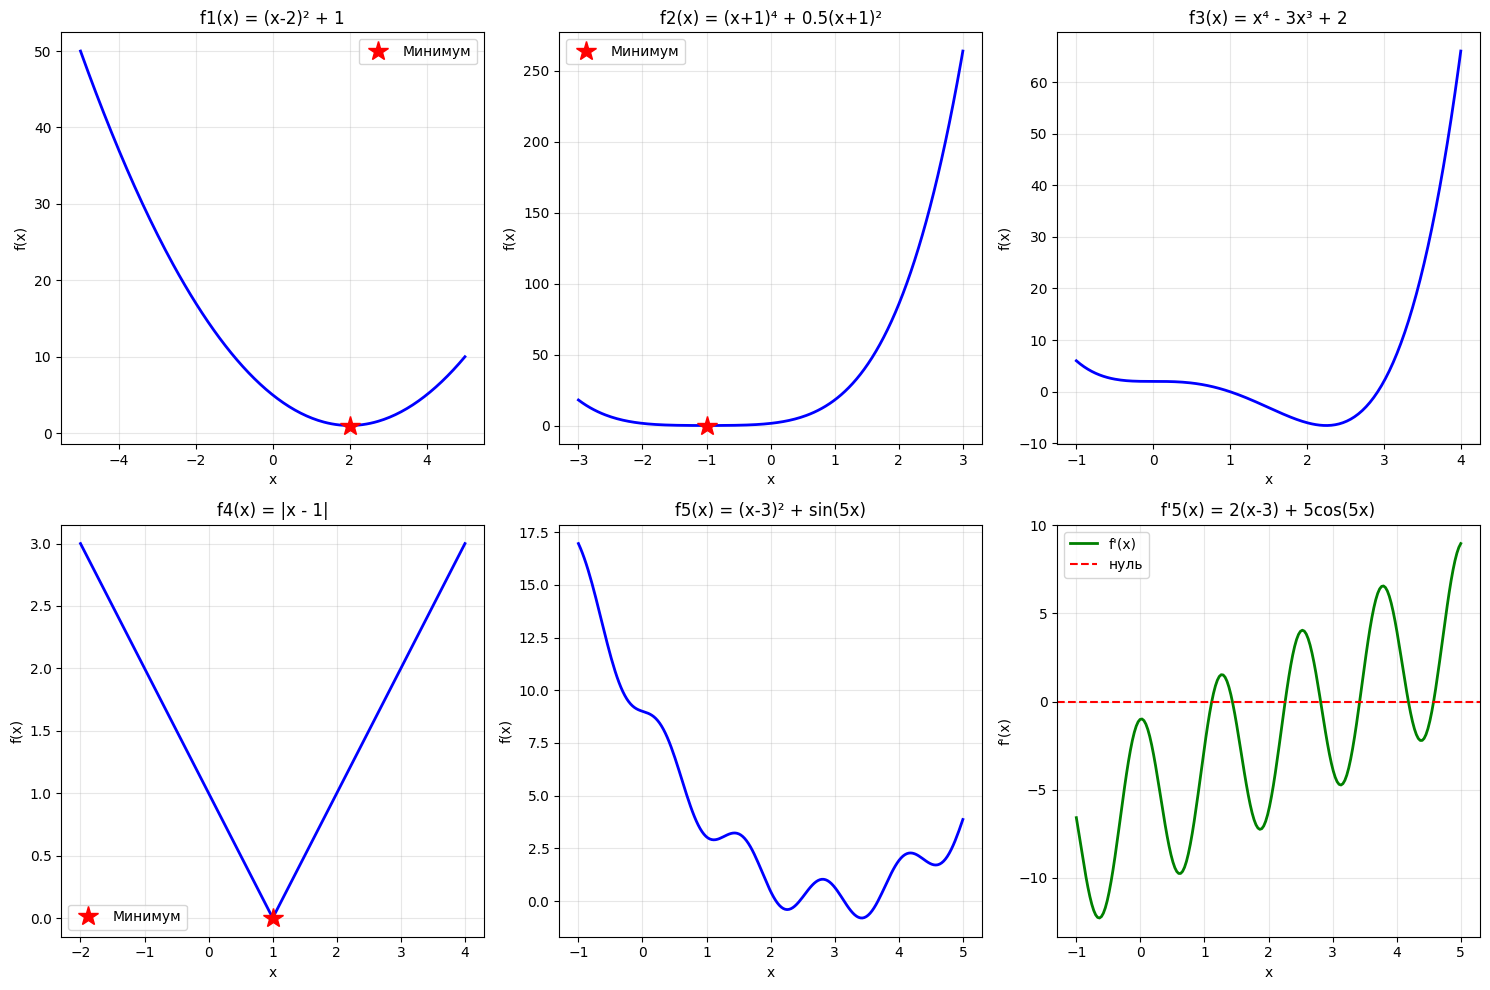

In [8]:
# Графики функций
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# f1
x_range = np.linspace(-5, 5, 200)
ax = axes[0, 0]
ax.plot(x_range, [f1(x) for x in x_range], 'b-', linewidth=2)
ax.plot(2, f1(2), 'r*', markersize=15, label='Минимум')
ax.set_title('f1(x) = (x-2)² + 1')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)
ax.legend()

# f2
x_range = np.linspace(-3, 3, 200)
ax = axes[0, 1]
ax.plot(x_range, [f2(x) for x in x_range], 'b-', linewidth=2)
ax.plot(-1, f2(-1), 'r*', markersize=15, label='Минимум')
ax.set_title('f2(x) = (x+1)⁴ + 0.5(x+1)²')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)
ax.legend()

# f3
x_range = np.linspace(-1, 4, 200)
ax = axes[0, 2]
ax.plot(x_range, [f3(x) for x in x_range], 'b-', linewidth=2)
ax.set_title('f3(x) = x⁴ - 3x³ + 2')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)

# f4
x_range = np.linspace(-2, 4, 200)
ax = axes[1, 0]
ax.plot(x_range, [f4(x) for x in x_range], 'b-', linewidth=2)
ax.plot(1, f4(1), 'r*', markersize=15, label='Минимум')
ax.set_title('f4(x) = |x - 1|')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)
ax.legend()

# f5
x_range = np.linspace(-1, 5, 200)
ax = axes[1, 1]
ax.plot(x_range, [f5(x) for x in x_range], 'b-', linewidth=2)
ax.set_title('f5(x) = (x-3)² + sin(5x)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)

# Производная f5
ax = axes[1, 2]
ax.plot(x_range, [df5(x) for x in x_range], 'g-', linewidth=2, label="f'(x)")
ax.axhline(y=0, color='r', linestyle='--', label='нуль')
ax.set_title("f'5(x) = 2(x-3) + 5cos(5x)")
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

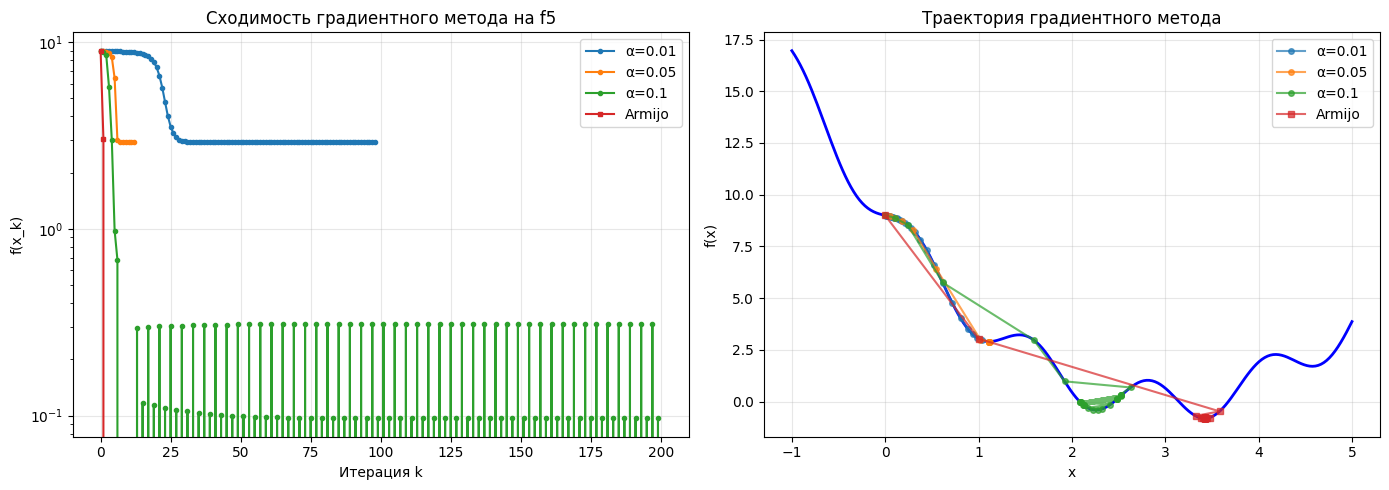

In [9]:
# Траектория сходимости градиентного метода
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# f(x_k) от k при разных шагах
ax = axes[0]
for alpha in [0.01, 0.05, 0.1]:
    x_opt, f_opt, iters, history = gradient_descent_fixed_step(f5, df5, 0.0, alpha=alpha, max_iter=200)
    f_vals = [f5(x) for x in history]
    ax.semilogy(range(len(f_vals)), f_vals, 'o-', label=f'α={alpha}', markersize=3)

x_opt, f_opt, iters, history, _ = gradient_descent_armijo(f5, df5, 0.0, max_iter=200)
f_vals = [f5(x) for x in history]
ax.semilogy(range(len(f_vals)), f_vals, 's-', label='Armijo', markersize=3)

ax.set_xlabel('Итерация k')
ax.set_ylabel('f(x_k)')
ax.set_title('Сходимость градиентного метода на f5')
ax.grid(True, alpha=0.3)
ax.legend()

# Траектория в пространстве (x, f(x))
ax = axes[1]
x_range = np.linspace(-1, 5, 200)
ax.plot(x_range, [f5(x) for x in x_range], 'b-', linewidth=2)

for alpha in [0.01, 0.05, 0.1]:
    x_opt, f_opt, iters, history = gradient_descent_fixed_step(f5, df5, 0.0, alpha=alpha, max_iter=50)
    f_vals = [f5(x) for x in history[:30]]
    ax.plot(history[:30], f_vals, 'o-', label=f'α={alpha}', markersize=4, alpha=0.7)

x_opt, f_opt, iters, history, _ = gradient_descent_armijo(f5, df5, 0.0, max_iter=50)
f_vals = [f5(x) for x in history[:30]]
ax.plot(history[:30], f_vals, 's-', label='Armijo', markersize=4, alpha=0.7)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Траектория градиентного метода')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Сравнительная таблица всех методов

In [11]:
import pandas as pd

# Сводная таблица
comparison_data = []

# f1
for name, res in results.items():
    for func_name, x_opt, f_opt, calls in res:
        if func_name == "f1":
            comparison_data.append({
                "Функция": "f1",
                "Метод": name,
                "x*": f"{x_opt:.8f}",
                "f(x*)": f"{f_opt:.8f}",
                "Вызовов f": calls
            })

# f2
for name, res in results.items():
    for func_name, x_opt, f_opt, calls in res:
        if func_name == "f2":
            comparison_data.append({
                "Функция": "f2",
                "Метод": name,
                "x*": f"{x_opt:.8f}",
                "f(x*)": f"{f_opt:.8f}",
                "Вызовов f": calls
            })

df_comparison = pd.DataFrame(comparison_data)
print("Сравнение методов сужения интервала:")
print(df_comparison.to_string(index=False))

Сравнение методов сужения интервала:
Функция     Метод          x*      f(x*)  Вызовов f
     f1 dichotomy  2.00000018 1.00000000         49
     f1    golden  1.99999996 1.00000000         36
     f1 parabolic  2.00000000 1.00000000          5
     f1    hybrid  2.00000000 1.00000000         51
     f2 dichotomy -1.00000012 0.00000000         47
     f2    golden -0.99999994 0.00000000         35
     f2 parabolic -1.00000000 0.00000000         11
     f2    hybrid -0.65522938 0.07356270         56


## Выводы

1. Методы сужения интервала (дихотомия, золотое сечение, интерполяция):
   - Дихотомия: надёжна, но требует больше вычислений
   - Золотое сечение: более эффективна, сокращает число вызовов функции
   - Параболическая интерполяция: быстра на гладких функциях, неустойчива на f4
   - Гибридный метод: объединяет надёжность и скорость

2. Методы с производными:
   - Бисекция (f'=0): работает только если производная меняет знак
   - Метод Ньютона: очень быстрая квадратичная сходимость, но требует f' и f''
   - Требует хорошего начального приближения

3. Градиентные методы:
   - Фиксированный шаг: простой, но требует тщательно выбрать α
   - Armijo line search: автоматический выбор шага, более надёжный
   - Требует только первую производную

Что и когда использовать:
   - Гладкие функции, производные известны → Ньютон или Armijo
   - Разреженные операции, нет производных → золотое сечение или гибридный метод
   - Функции с острыми вершинами (f4) → методы без производных
   - Многомерная оптимизация → неточный line search (Armijo)